# 5.0 — Data Preparation (v3)
**Thesis:** Unsupervised Deep Learning for Parkinson's Disease Imaging
**Author:** Natnael Solomon Gebremichael — UniMiB MSc Data Science

## What this notebook does
1. Loads train and val latent vector files (β = 3×10⁻⁵) separately
2. Extracts scan date from file_path (no EVENT_ID in new files)
3. Loads and preprocesses UPDRS-III (OFF state, NP3TOT) and MoCA
4. Merges clinical data using PATNO + scan date
5. Checks patient overlap between train and val files
6. Fits SBR PCA once on training set and saves fitted objects
7. Runs inter-clinical variable correlation check
8. Saves final train.csv and val.csv

## Changes from v2
- Uses two separate latent files (train + val) provided by professor
- No internal patient-stratified split — professor's files already separated
- Date-based merge instead of EVENT_ID (new files have no EVENT_ID)
- ±1 month fallback for date mismatches


## 1. Imports and Configuration

In [9]:
# [IMPORTS]
import pandas as pd
import numpy as np
import pickle
import os
import re
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [10]:
# [CONFIG]
# ── File paths ─────────────────────────────────────────────────────────────────
LATENT_TRAIN_FILE = '../../data/baseline/train_mu_beta_3.00e-05.csv'
LATENT_VAL_FILE   = '../../data/baseline/val_mu_beta_3.00e-05.csv'

CLINICAL_DIR   = '../../data/raw/ppmi_clinical/'
UPDRS_III_FILE = os.path.join(CLINICAL_DIR, 'MDS-UPDRS_Part_III_06Jul2026.csv')
MOCA_FILE      = os.path.join(CLINICAL_DIR, 'Montreal_Cognitive_Assessment__MoCA__08Jul2026.csv')

TRAIN_OUT  = '../../data/processed/clinical_merged/train_v3.csv'
VAL_OUT    = '../../data/processed/clinical_merged/val_v3.csv'
SCALER_OUT = '../../results/models/scaler_sbr_v3.pkl'
PCA_OUT    = '../../results/models/pca_sbr_v3.pkl'

os.makedirs('../../data/processed/clinical_merged', exist_ok=True)
os.makedirs('../../results/models', exist_ok=True)

# ── Parameters ─────────────────────────────────────────────────────────────────
PATIENT_COL  = 'PATNO'
LABEL_COL    = 'label'
RANDOM_STATE = 42
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]
N_SBR_PCS = 3

print("Configuration loaded.")

Configuration loaded.


## 2. Helper Functions

In [11]:
# [HELPER-FUNCTIONS] — simplified version without in-place assignment

def extract_scan_month(df, filepath_col='file_path'):
    """
    Extract scan month (MM/YYYY) from file path.
    Drops rows with invalid placeholder dates (9999-xx-xx).
    """
    df = df.copy()
    df['scan_date'] = df[filepath_col].str.extract(r'(\d{4}-\d{2}-\d{2})')
    valid_mask = ~df['scan_date'].str.startswith('9999', na=True)
    n_dropped  = (~valid_mask).sum()
    df = df[valid_mask].copy().reset_index(drop=True)
    df['scan_month'] = pd.to_datetime(
        df['scan_date'], format='%Y-%m-%d'
    ).dt.strftime('%m/%Y')
    print(f"  Date extraction: {len(df)} valid rows, {n_dropped} invalid dropped")
    return df


def merge_on_date(df_base, df_clinical, clinical_cols,
                  base_date_col='scan_month',
                  clinical_date_col='INFODT',
                  label='clinical'):
    """
    Merge df_base with df_clinical on PATNO + visit date (MM/YYYY).
    Two-step approach:
      1. Exact match on PATNO + date
      2. ±1 month fallback for unmatched rows
    Avoids in-place assignment by doing two separate merges and combining.
    """
    df_base     = df_base.reset_index(drop=True)
    df_clinical = df_clinical.copy()

    # Standardise clinical date to MM/YYYY
    df_clinical[clinical_date_col] = pd.to_datetime(
        df_clinical[clinical_date_col], format='%m/%Y', errors='coerce'
    ).dt.strftime('%m/%Y')

    # Deduplicate — one record per PATNO + date
    df_clinical = df_clinical.drop_duplicates(
        subset=['PATNO', clinical_date_col], keep='first'
    ).reset_index(drop=True)

    cols_to_merge = ['PATNO', clinical_date_col] + clinical_cols

    # Step 1 — exact date match
    matched = df_base.merge(
        df_clinical[cols_to_merge].rename(columns={clinical_date_col: base_date_col}),
        on=['PATNO', base_date_col],
        how='inner'
    )
    n_exact = len(matched)

    # Rows not matched in step 1
    matched_idx   = df_base.merge(
        df_clinical[['PATNO', clinical_date_col]].rename(
            columns={clinical_date_col: base_date_col}
        ),
        on=['PATNO', base_date_col],
        how='inner'
    ).index

    unmatched = df_base[~df_base.index.isin(matched_idx)].reset_index(drop=True)

    # Step 2 — ±1 month fallback on unmatched rows
    fallback_results = []
    for delta in [-1, 1]:
        if len(unmatched) == 0:
            break

        unmatched_shifted = unmatched.copy()
        unmatched_shifted['_shifted'] = (
            pd.to_datetime(unmatched_shifted[base_date_col], format='%m/%Y')
            + pd.DateOffset(months=delta)
        ).dt.strftime('%m/%Y')

        fb = unmatched_shifted.merge(
            df_clinical[cols_to_merge].rename(columns={clinical_date_col: '_shifted'}),
            on=['PATNO', '_shifted'],
            how='inner'
        ).drop(columns=['_shifted'])

        if len(fb) > 0:
            fallback_results.append(fb)
            # Remove newly matched from unmatched
            unmatched = unmatched[
                ~unmatched['PATNO'].isin(fb['PATNO'])
            ].reset_index(drop=True)

    # Combine matched + fallback + unmatched (with NaN for clinical cols)
    parts = [matched]
    if fallback_results:
        parts.extend(fallback_results)
    if len(unmatched) > 0:
        for col in clinical_cols:
            unmatched[col] = np.nan
        parts.append(unmatched)

    result = pd.concat(parts, ignore_index=True)

    n_total     = result[clinical_cols[0]].notna().sum()
    n_recovered = n_total - n_exact

    print(f"  {label}:")
    print(f"    Exact match:       {n_exact}")
    print(f"    ±1 month fallback: {n_recovered}")
    print(f"    Total matched:     {n_total} / {len(df_base)} ({n_total/len(df_base)*100:.1f}%)")
    print()
    return result

print("Helper functions defined.")

Helper functions defined.


## 3. Load Latent Vectors

In [12]:
# [LOAD-LATENTS]
df_latents_train = pd.read_csv(LATENT_TRAIN_FILE)
df_latents_val   = pd.read_csv(LATENT_VAL_FILE)

print("=== Train latent file ===")
print(f"Shape:           {df_latents_train.shape}")
print(f"Unique patients: {df_latents_train[PATIENT_COL].nunique()}")
print(f"Label counts:\n{df_latents_train[LABEL_COL].value_counts().to_string()}")

print("\n=== Val latent file ===")
print(f"Shape:           {df_latents_val.shape}")
print(f"Unique patients: {df_latents_val[PATIENT_COL].nunique()}")
print(f"Label counts:\n{df_latents_val[LABEL_COL].value_counts().to_string()}")

# Check patient overlap
train_patnos = set(df_latents_train[PATIENT_COL].unique())
val_patnos   = set(df_latents_val[PATIENT_COL].unique())
overlap      = train_patnos & val_patnos
print(f"\nPatient overlap between files: {len(overlap)}")
print("✓ Clean split" if len(overlap) == 0 else f"⚠ WARNING — {len(overlap)} patients in both files")

=== Train latent file ===
Shape:           (3095, 259)
Unique patients: 1854
Label counts:
label
PD         2683
Control     302
SWEDD       110

=== Val latent file ===
Shape:           (774, 259)
Unique patients: 666
Label counts:
label
PD         671
Control     76
SWEDD       27

Patient overlap between files: 422
⚠ WARNING — 422 patients in both files


## 4. Extract Scan Date from File Path
New latent files have no EVENT_ID — we extract the scan date from the file path
and use it to match clinical visit records (INFODT in MM/YYYY format).


In [13]:
# [EXTRACT-SCAN-DATE]
print("=== Extracting scan dates ===")
print("Train:")
df_train = extract_scan_month(df_latents_train)
print("Val:")
df_val   = extract_scan_month(df_latents_val)

print(f"\nSample scan months (train):")
print(df_train[['PATNO', 'scan_date', 'scan_month']].head(5).to_string())

=== Extracting scan dates ===
Train:
  Date extraction: 3092 valid rows, 3 invalid dropped
Val:
  Date extraction: 774 valid rows, 0 invalid dropped

Sample scan months (train):
    PATNO   scan_date scan_month
0    3773  2013-03-14    03/2013
1    3825  2014-07-22    07/2014
2    3593  2017-03-17    03/2017
3  253774  2023-06-27    06/2023
4    3387  2017-02-01    02/2017


## 5. Load Clinical Tables

In [14]:
# [LOAD-UPDRS3]
# UPDRS-III — apply OFF state filter, keep INFODT for date-based merge
df_updrs3_raw = pd.read_csv(UPDRS_III_FILE)

df_updrs3 = df_updrs3_raw[
    (df_updrs3_raw['PDSTATE'] == 'OFF') | (df_updrs3_raw['PDSTATE'].isna())
].copy()

df_updrs3 = df_updrs3[['PATNO', 'EVENT_ID', 'INFODT', 'NP3TOT', 'NHY']].dropna(subset=['NP3TOT'])
df_updrs3 = df_updrs3.rename(columns={'NP3TOT': 'UPDRS3_TOTAL', 'NHY': 'HOEHN_YAHR'})

print("=== UPDRS-III (OFF state) ===")
print(f"Rows:            {len(df_updrs3)}")
print(f"Unique patients: {df_updrs3[PATIENT_COL].nunique()}")
print(f"Score range:     {df_updrs3['UPDRS3_TOTAL'].min():.0f} – {df_updrs3['UPDRS3_TOTAL'].max():.0f}")
print(f"Sample INFODT:   {df_updrs3['INFODT'].head(3).tolist()}")

=== UPDRS-III (OFF state) ===
Rows:            23405
Unique patients: 5151
Score range:     0 – 100
Sample INFODT:   ['02/2011', '03/2012', '02/2013']


In [15]:
# [LOAD-MOCA]
# MoCA
df_moca_raw = pd.read_csv(MOCA_FILE)
df_moca = df_moca_raw[['PATNO', 'EVENT_ID', 'INFODT', 'MCATOT']].dropna(subset=['MCATOT'])
df_moca = df_moca.rename(columns={'MCATOT': 'MOCA_TOTAL'})

print("=== MoCA ===")
print(f"Rows:            {len(df_moca)}")
print(f"Unique patients: {df_moca[PATIENT_COL].nunique()}")
print(f"Score range:     {df_moca['MOCA_TOTAL'].min():.0f} – {df_moca['MOCA_TOTAL'].max():.0f}")
print(f"Sample INFODT:   {df_moca['INFODT'].head(3).tolist()}")

=== MoCA ===
Rows:            19974
Unique patients: 5478
Score range:     0 – 30
Sample INFODT:   ['01/2011', '03/2012', '02/2013']


## 6. Merge Clinical Data
Date-based merge on PATNO + scan_month (MM/YYYY).
Two-step: exact match first, then ±1 month fallback for mismatches.
Applied separately to train and val.


In [16]:
# [MERGE-TRAIN]
print("=== Merging clinical data — TRAIN ===\n")
df_train = merge_on_date(df_train, df_updrs3, ['UPDRS3_TOTAL', 'HOEHN_YAHR'],
                         clinical_date_col='INFODT', label='UPDRS-III + H&Y')
df_train = merge_on_date(df_train, df_moca, ['MOCA_TOTAL'],
                         clinical_date_col='INFODT', label='MoCA')
print(f"Train final shape: {df_train.shape}")

=== Merging clinical data — TRAIN ===

  UPDRS-III + H&Y:
    Exact match:       1574
    ±1 month fallback: 372
    Total matched:     1946 / 3092 (62.9%)

  MoCA:
    Exact match:       2256
    ±1 month fallback: 66
    Total matched:     2322 / 2939 (79.0%)

Train final shape: (2928, 264)


In [17]:
# [MERGE-VAL]
print("=== Merging clinical data — VAL ===\n")
df_val = merge_on_date(df_val, df_updrs3, ['UPDRS3_TOTAL', 'HOEHN_YAHR'],
                       clinical_date_col='INFODT', label='UPDRS-III + H&Y')
df_val = merge_on_date(df_val, df_moca, ['MOCA_TOTAL'],
                       clinical_date_col='INFODT', label='MoCA')
print(f"Val final shape: {df_val.shape}")

=== Merging clinical data — VAL ===

  UPDRS-III + H&Y:
    Exact match:       385
    ±1 month fallback: 94
    Total matched:     479 / 774 (61.9%)

  MoCA:
    Exact match:       574
    ±1 month fallback: 13
    Total matched:     587 / 760 (77.2%)

Val final shape: (760, 264)


## 7. Coverage Report

In [18]:
# [COVERAGE-REPORT]
CLINICAL_COLS = ['UPDRS3_TOTAL', 'HOEHN_YAHR', 'MOCA_TOTAL']

for split_name, df_split in [('Train', df_train), ('Val', df_val)]:
    print(f"=== {split_name} coverage ===")
    print(f"{'Variable':<20} {'Non-null':>10} {'Coverage':>10}")
    print("-" * 42)
    for col in CLINICAL_COLS:
        n   = df_split[col].notna().sum()
        pct = n / len(df_split) * 100
        print(f"  {col:<18} {n:>10} {pct:>9.1f}%")
    print()

=== Train coverage ===
Variable               Non-null   Coverage
------------------------------------------
  UPDRS3_TOTAL             1581      54.0%
  HOEHN_YAHR               1581      54.0%
  MOCA_TOTAL               2322      79.3%

=== Val coverage ===
Variable               Non-null   Coverage
------------------------------------------
  UPDRS3_TOTAL              386      50.8%
  HOEHN_YAHR                386      50.8%
  MOCA_TOTAL                587      77.2%



## 8. Inter-Clinical Variable Correlation
Check whether selected clinical variables are correlated with each other.


=== Spearman correlation between clinical variables ===
              UPDRS3_TOTAL  MOCA_TOTAL  HOEHN_YAHR
UPDRS3_TOTAL         1.000      -0.146       0.651
MOCA_TOTAL          -0.146       1.000      -0.138
HOEHN_YAHR           0.651      -0.138       1.000


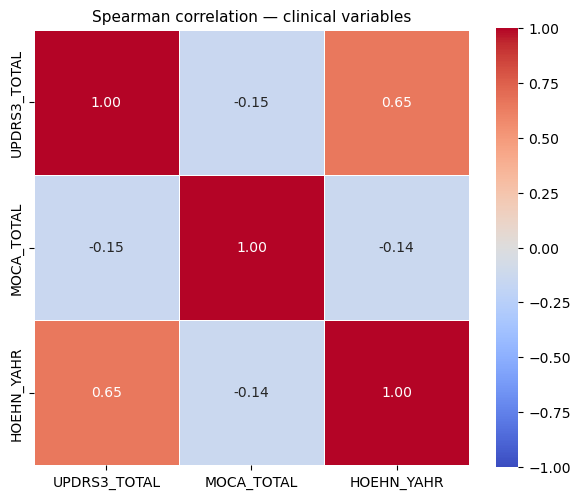

Saved: results/figures/clinical_correlation_v3.png


In [19]:
# [INTER-CLINICAL-CORRELATION]
corr_cols = [c for c in ['UPDRS3_TOTAL', 'MOCA_TOTAL', 'HOEHN_YAHR', 'AGE_AT_VISIT']
             if c in df_train.columns]

corr_matrix = df_train[corr_cols].corr(method='spearman')

print("=== Spearman correlation between clinical variables ===")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Spearman correlation — clinical variables', fontsize=11)
plt.tight_layout()
plt.savefig('../../results/figures/clinical_correlation_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/clinical_correlation_v3.png")

## 9. SBR PCA — Fit Once on Training Set
Note: if SBR columns are not present in the new latent files,
this section will be updated once the new Xing Core Lab SBR file is downloaded (DAI-126).


In [20]:
# [SBR-PCA-FIT]
# Check if SBR columns exist in the merged train file
sbr_available = [c for c in SBR_COLS if c in df_train.columns]
print(f"SBR columns available: {len(sbr_available)} / {len(SBR_COLS)}")
print(sbr_available)

if len(sbr_available) == len(SBR_COLS):
    # Fit on training set only
    df_train_sbr = df_train.dropna(subset=SBR_COLS).copy()
    df_val_sbr   = df_val.dropna(subset=SBR_COLS).copy()

    scaler_sbr = StandardScaler()
    sbr_train_scaled = scaler_sbr.fit_transform(df_train_sbr[SBR_COLS])

    pca_sbr = PCA(n_components=N_SBR_PCS, random_state=RANDOM_STATE)
    sbr_train_pcs = pca_sbr.fit_transform(sbr_train_scaled)

    for i in range(N_SBR_PCS):
        df_train.loc[df_train_sbr.index, f'SBR_PC{i+1}'] = sbr_train_pcs[:, i]

    sbr_val_scaled = scaler_sbr.transform(df_val_sbr[SBR_COLS])
    sbr_val_pcs    = pca_sbr.transform(sbr_val_scaled)
    for i in range(N_SBR_PCS):
        df_val.loc[df_val_sbr.index, f'SBR_PC{i+1}'] = sbr_val_pcs[:, i]

    with open(SCALER_OUT, 'wb') as f: pickle.dump(scaler_sbr, f)
    with open(PCA_OUT,    'wb') as f: pickle.dump(pca_sbr, f)

    print(f"\nSBR PCA explained variance: {pca_sbr.explained_variance_ratio_.round(3)}")
    print(f"Total explained:             {pca_sbr.explained_variance_ratio_.sum()*100:.1f}%")
    print(f"Saved: {SCALER_OUT}")
    print(f"Saved: {PCA_OUT}")
else:
    print("\nSBR columns not available in new latent files.")
    print("Will be updated after downloading Xing Core Lab SBR file (DAI-126).")

SBR columns available: 0 / 6
[]

SBR columns not available in new latent files.
Will be updated after downloading Xing Core Lab SBR file (DAI-126).


## 10. Save Final Files

In [21]:
# [SAVE-FILES]
df_train.to_csv(TRAIN_OUT, index=False)
df_val.to_csv(VAL_OUT,     index=False)

print("=== Files saved ===")
print(f"\nTrain: {TRAIN_OUT}")
print(f"  Shape:           {df_train.shape}")
print(f"  Unique patients: {df_train[PATIENT_COL].nunique()}")
print(f"  Labels:          {df_train[LABEL_COL].value_counts().to_dict()}")

print(f"\nVal: {VAL_OUT}")
print(f"  Shape:           {df_val.shape}")
print(f"  Unique patients: {df_val[PATIENT_COL].nunique()}")
print(f"  Labels:          {df_val[LABEL_COL].value_counts().to_dict()}")

print(f"\nClinical coverage (train):")
for col in CLINICAL_COLS:
    if col in df_train.columns:
        pct = df_train[col].notna().mean() * 100
        print(f"  {col:<20} {pct:.1f}%")

=== Files saved ===

Train: ../../data/processed/clinical_merged/train_v3.csv
  Shape:           (2928, 264)
  Unique patients: 1196
  Labels:          {'PD': 2607, 'Control': 174, 'SWEDD': 147}

Val: ../../data/processed/clinical_merged/val_v3.csv
  Shape:           (760, 264)
  Unique patients: 419
  Labels:          {'PD': 683, 'Control': 43, 'SWEDD': 34}

Clinical coverage (train):
  UPDRS3_TOTAL         54.0%
  HOEHN_YAHR           54.0%
  MOCA_TOTAL           79.3%


## 11. Summary

| Item | v2 | v3 (this notebook) |
|---|---|---|
| Latent files | One file, split internally | Two files, professor's split |
| Join key | PATNO + EVENT_ID | PATNO + scan date (MM/YYYY) |
| Date source | EVENT_ID column | Extracted from file_path |
| Fallback | SC↔BL EVENT_ID swap | ±1 month date fallback |
| Patient split | Internal (removed) | Professor's files |
| SBR PCA | Fitted once ✓ | Fitted once if columns available |
